#  DATATHON 2026 
## Phần 3: Mô hình Dự báo Doanh thu 


## 0. Cài đặt thư viện

In [1]:
import lightgbm
import shap
import lunardate
import optuna
print(" Tất cả thư viện đã sẵn sàng")

 Tất cả thư viện đã sẵn sàng


## 1. Import & Cấu hình toàn cục

In [2]:
import numpy as np
import pandas as pd
import os, warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import shap
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

from lunardate import LunarDate
SEED = 42
np.random.seed(SEED)


DATA_PATH = r"D:\Datathon2026_DataFusion4\data\processed"

# ─── Train / Test split dates (theo đề thi) ──────────────────────────
TRAIN_START = pd.Timestamp('2012-07-04')
TRAIN_END   = pd.Timestamp('2022-12-31')
TEST_START  = pd.Timestamp('2023-01-01')
TEST_END    = pd.Timestamp('2024-07-01')

print(f'Train: {TRAIN_START.date()} → {TRAIN_END.date()}')
print(f'Test : {TEST_START.date()} → {TEST_END.date()}')
print(f' Seed = {SEED}')

Train: 2012-07-04 → 2022-12-31
Test : 2023-01-01 → 2024-07-01
 Seed = 42


## 2. Data Collection & Preprocessing

In [3]:

sales             = pd.read_csv(os.path.join(DATA_PATH, 'sales.csv'),
                                parse_dates=['Date'])
sample_submission = pd.read_csv(os.path.join(DATA_PATH, 'sample_submission.csv'),
                                parse_dates=['Date'])
web_traffic       = pd.read_csv(os.path.join(DATA_PATH, 'web_traffic.csv'),
                                parse_dates=['date'])
inventory         = pd.read_csv(os.path.join(DATA_PATH, 'inventory.csv'),
                                parse_dates=['snapshot_date'])

# ─── Kiểm tra train/test split KHÔNG overlap ─────────────────────────
train_max = sales['Date'].max()
test_min  = sample_submission['Date'].min()

assert train_max <= TRAIN_END,  f'sales.csv chứa ngày vượt TRAIN_END: {train_max}'
assert test_min  >= TEST_START, f'sample_submission chứa ngày trước TEST_START: {test_min}'
assert train_max < test_min,    'LEAKAGE: train và test bị overlap!'

print('=== Kiểm tra dữ liệu ===')
print(f'Train (sales.csv)          : {sales.shape}  | {sales["Date"].min().date()} → {sales["Date"].max().date()}')
print(f'Test  (sample_submission)  : {sample_submission.shape} | {sample_submission["Date"].min().date()} → {sample_submission["Date"].max().date()}')
print(f'Web traffic                : {web_traffic.shape}')
print(f'Inventory                  : {inventory.shape}')
print(f'\n Train kết thúc: {train_max.date()} | Test bắt đầu: {test_min.date()}')
print(f' Gap = {(test_min - train_max).days} ngày — không có data leakage')

=== Kiểm tra dữ liệu ===
Train (sales.csv)          : (3833, 3)  | 2012-07-04 → 2022-12-31
Test  (sample_submission)  : (548, 3) | 2023-01-01 → 2024-07-01
Web traffic                : (3652, 7)
Inventory                  : (60247, 17)

 Train kết thúc: 2022-12-31 | Test bắt đầu: 2023-01-01
 Gap = 1 ngày — không có data leakage


### 2.1 Chuẩn bị External Signals (Web Traffic & Inventory)

In [4]:
# --- Web Traffic: tổng sessions mỗi ngày ---
web_daily = (
    web_traffic
    .groupby('date', as_index=False)['sessions']
    .sum()
    .rename(columns={'date': 'Date', 'sessions': 'daily_sessions'})
)

# --- Stockout: % SKU bị hết hàng mỗi tháng → forward-fill xuống ngày ---
stockout_monthly = (
    inventory
    .groupby('snapshot_date', as_index=False)['stockout_flag']
    .mean()
    .rename(columns={'snapshot_date': 'Date', 'stockout_flag': 'stockout_rate'})
)

all_dates = pd.date_range(TRAIN_START, TEST_END, freq='D')
stockout_daily = (
    pd.DataFrame({'Date': all_dates})
    .merge(stockout_monthly, on='Date', how='left')
    .sort_values('Date')
)
stockout_daily['stockout_rate'] = stockout_daily['stockout_rate'].ffill().fillna(0)

print('Web traffic daily :', web_daily.shape)
print('Stockout daily    :', stockout_daily.shape)

Web traffic daily : (3652, 2)
Stockout daily    : (4381, 2)


## 3. Feature Engineering


In [5]:
# ─── 3.1 Tết Nguyên Đán & Mega Sale calendar ────────────────────────
tet_map = {}
for year in range(2012, 2027):
    tet_map[year] = pd.Timestamp(LunarDate(year, 1, 1).toSolarDate())

MEGA_SALE_DAYS = {(9, 9), (10, 10), (11, 11), (12, 12)}
mega_dates = sorted([
    pd.Timestamp(year=y, month=m, day=d)
    for y in range(2012, 2026)
    for m, d in MEGA_SALE_DAYS
])

print('Tết 5 năm gần nhất:')
for y, d in list(tet_map.items())[-5:]:
    print(f'  {y}: {d.date()}')

Tết 5 năm gần nhất:
  2022: 2022-02-01
  2023: 2023-01-22
  2024: 2024-02-10
  2025: 2025-01-29
  2026: 2026-02-17


In [6]:
def days_to_next_event(date, event_list):
    future = [e for e in event_list if e >= date]
    return (future[0] - date).days if future else 999


def build_features(df, target_col='log_revenue', cogs_col='log_cogs'):
    """
    Xây dựng feature trên log scale — tránh data leakage.
    Tất cả lag/rolling đều dùng shift(1) để không thấy giá trị hiện tại.
    
    FIX Bonus: rev_ratio_7_30 dùng log-ratio thay vì raw ratio.
    """
    df = df.sort_values('Date').reset_index(drop=True)

    # ── 1. Time features ──────────────────────────────────────────────
    df['month']      = df['Date'].dt.month
    df['day']        = df['Date'].dt.day
    df['dayofweek']  = df['Date'].dt.dayofweek
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['quarter']    = df['Date'].dt.quarter
    df['dayofyear']  = df['Date'].dt.dayofyear
    df['week']       = df['Date'].dt.isocalendar().week.astype(int)

    # ── 2. Tết features ───────────────────────────────────────────────
    df['tet_date']    = df['Date'].dt.year.map(tet_map)
    df['days_to_tet'] = (df['Date'] - df['tet_date']).dt.days
    df['is_pre_tet']  = df['days_to_tet'].between(-20, -1).astype(int)
    df['is_tet']      = df['days_to_tet'].between(0, 7).astype(int)
    df['is_post_tet'] = df['days_to_tet'].between(8, 22).astype(int)
    df.drop(columns=['tet_date'], inplace=True)

    # ── 3. Mega sale flags ────────────────────────────────────────────
    month_day = list(zip(df['month'], df['day']))
    df['is_mega_sale'] = [1 if md in MEGA_SALE_DAYS else 0 for md in month_day]
    df['is_1111']      = ((df['month'] == 11) & (df['day'] == 11)).astype(int)
    df['is_1212']      = ((df['month'] == 12) & (df['day'] == 12)).astype(int)

    # ── 4. Countdown features ─────────────────────────────────────────
    tet_dates_list = sorted(tet_map.values())
    df['days_to_next_mega'] = df['Date'].apply(
        lambda d: days_to_next_event(d, mega_dates)
    ).clip(0, 90)
    df['days_to_next_tet'] = df['Date'].apply(
        lambda d: days_to_next_event(d, tet_dates_list)
    ).clip(0, 90)

    # ── 5. Lag features ───────────────────────────────────────────────
    for lag in [1, 7, 14, 30, 365]:
        df[f'rev_lag_{lag}'] = df[target_col].shift(lag)

    # ── 6. Rolling stats ──────────────────────────────────────────────
    df['rev_roll_mean_7']  = df[target_col].shift(1).rolling(7).mean()
    df['rev_roll_mean_14'] = df[target_col].shift(1).rolling(14).mean()
    df['rev_roll_mean_30'] = df[target_col].shift(1).rolling(30).mean()
    df['rev_roll_mean_60'] = df[target_col].shift(1).rolling(60).mean()
    df['rev_roll_std_7']   = df[target_col].shift(1).rolling(7).std()
    df['rev_roll_std_30']  = df[target_col].shift(1).rolling(30).std()
    df['rev_trend']        = df['rev_roll_mean_7'] - df['rev_roll_mean_30']

    # ── 7. COGS lag ───────────────────────────────────────────────────
    if cogs_col in df.columns:
        for lag in [1, 7]:
            df[f'cogs_lag_{lag}'] = df[cogs_col].shift(lag)

    # ── 8. Momentum ───────────────────────────────────────────────────
    df['rev_momentum_14'] = df['rev_roll_mean_7'] - df[target_col].shift(14)

    df['rev_ratio_7_30'] = (
        np.log1p(df['rev_roll_mean_7'].clip(lower=0))
        - np.log1p(df['rev_roll_mean_30'].clip(lower=0))
    )

    # ── 10. Fourier seasonality ───────────────────────────────────────
    df['sin_week']  = np.sin(2 * np.pi * df['dayofyear'] / 365.25)
    df['cos_week']  = np.cos(2 * np.pi * df['dayofyear'] / 365.25)
    df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
    df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)

    return df


print(' build_features() đã định nghĩa')

 build_features() đã định nghĩa


### 3.2 Ghép External Signals & Log Transform

In [7]:
df_full = (
    sales
    .merge(web_daily,      on='Date', how='left')
    .merge(stockout_daily, on='Date', how='left')
)
df_full['daily_sessions'] = df_full['daily_sessions'].fillna(df_full['daily_sessions'].median())
df_full['stockout_rate']  = df_full['stockout_rate'].fillna(0)

df_full['log_revenue'] = np.log1p(df_full['Revenue'])
df_full['log_cogs']    = np.log1p(df_full['COGS'])

df_full = build_features(df_full, target_col='log_revenue', cogs_col='log_cogs')

EXCLUDE_COLS = {'Date', 'Revenue', 'COGS', 'log_revenue', 'log_cogs'}
FEATURE_COLS = [c for c in df_full.columns if c not in EXCLUDE_COLS]

df_train = df_full.dropna(subset=FEATURE_COLS).copy()

X          = df_train[FEATURE_COLS].values
y_log_rev  = df_train['log_revenue'].values
y_log_cogs = df_train['log_cogs'].values

print(f'Shape df_full  : {df_full.shape}')
print(f'Train rows dùng: {len(df_train)} | {df_train["Date"].min().date()} → {df_train["Date"].max().date()}')
print(f'Số features    : {len(FEATURE_COLS)}')
print(FEATURE_COLS)

Shape df_full  : (3833, 43)
Train rows dùng: 3468 | 2013-07-04 → 2022-12-31
Số features    : 38
['daily_sessions', 'stockout_rate', 'month', 'day', 'dayofweek', 'is_weekend', 'quarter', 'dayofyear', 'week', 'days_to_tet', 'is_pre_tet', 'is_tet', 'is_post_tet', 'is_mega_sale', 'is_1111', 'is_1212', 'days_to_next_mega', 'days_to_next_tet', 'rev_lag_1', 'rev_lag_7', 'rev_lag_14', 'rev_lag_30', 'rev_lag_365', 'rev_roll_mean_7', 'rev_roll_mean_14', 'rev_roll_mean_30', 'rev_roll_mean_60', 'rev_roll_std_7', 'rev_roll_std_30', 'rev_trend', 'cogs_lag_1', 'cogs_lag_7', 'rev_momentum_14', 'rev_ratio_7_30', 'sin_week', 'cos_week', 'sin_month', 'cos_month']


## 4. Model Selection — Baseline

In [8]:
split_idx = int(len(X) * 0.8)
X_bl_tr, X_bl_val = X[:split_idx], X[split_idx:]
y_bl_tr, y_bl_val = y_log_rev[:split_idx], y_log_rev[split_idx:]

baseline_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge',  Ridge(alpha=1.0, random_state=SEED))
])
baseline_pipeline.fit(X_bl_tr, y_bl_tr)
y_bl_pred_log = baseline_pipeline.predict(X_bl_val)

y_bl_pred = np.expm1(y_bl_pred_log)
y_bl_true = np.expm1(y_bl_val)

bl_mae  = mean_absolute_error(y_bl_true, y_bl_pred)
bl_rmse = np.sqrt(mean_squared_error(y_bl_true, y_bl_pred))
bl_r2   = r2_score(y_bl_true, y_bl_pred)

print('=== BASELINE: Ridge Regression ===')
print(f'  MAE  = {bl_mae:>12,.0f}')
print(f'  RMSE = {bl_rmse:>12,.0f}')
print(f'  R²   = {bl_r2:>12.4f}')
print()
print('Mục tiêu: LightGBM phải vượt các chỉ số này.')

=== BASELINE: Ridge Regression ===
  MAE  =      617,424
  RMSE =      880,270
  R²   =       0.7206

Mục tiêu: LightGBM phải vượt các chỉ số này.


## 5. Initial Training & Cross-Validation (Walk-forward)


In [9]:

BASE_PARAMS = {
    'objective':              'huber',
    'alpha':                  0.5,
    'n_estimators':           2000,
    'learning_rate':          0.03,

    # Complexity — cân bằng: 
    'num_leaves':             24,        
    'max_depth':              6,         
    'min_child_samples':      70,      
    'min_gain_to_split':      0.05,   

    # Subsampling
    'subsample':              0.65,      
    'colsample_bytree':       0.65,     
    'feature_fraction_bynode': 0.7,      

    # Regularization L1/L2
    'reg_alpha':              0.4,      
    'reg_lambda':             3.5,       

    'random_state':           SEED,
    'n_jobs':                 -1,
    'verbose':                -1,
}

tscv = TimeSeriesSplit(n_splits=5)
cv_scores_rev  = {'mae': [], 'rmse': [], 'r2': []}
cv_scores_cogs = {'mae': [], 'rmse': [], 'r2': []}
best_iters_rev  = []
best_iters_cogs = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_val   = X[train_idx], X[val_idx]
    yr_tr, yr_val = y_log_rev[train_idx],  y_log_rev[val_idx]
    yc_tr, yc_val = y_log_cogs[train_idx], y_log_cogs[val_idx]

    model_rev = lgb.LGBMRegressor(**BASE_PARAMS)
    model_rev.fit(
        X_tr, yr_tr,
        eval_set=[(X_val, yr_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )
    best_iters_rev.append(model_rev.best_iteration_)

    model_cogs = lgb.LGBMRegressor(**BASE_PARAMS)
    model_cogs.fit(
        X_tr, yc_tr,
        eval_set=[(X_val, yc_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )
    best_iters_cogs.append(model_cogs.best_iteration_)

    pred_rev_orig  = np.expm1(model_rev.predict(X_val))
    yr_val_orig    = np.expm1(yr_val)
    pred_cogs_orig = np.expm1(model_cogs.predict(X_val))
    yc_val_orig    = np.expm1(yc_val)

    mae_r  = mean_absolute_error(yr_val_orig, pred_rev_orig)
    rmse_r = np.sqrt(mean_squared_error(yr_val_orig, pred_rev_orig))
    r2_r   = r2_score(yr_val_orig, pred_rev_orig)
    cv_scores_rev['mae'].append(mae_r)
    cv_scores_rev['rmse'].append(rmse_r)
    cv_scores_rev['r2'].append(r2_r)

    mae_c  = mean_absolute_error(yc_val_orig, pred_cogs_orig)
    rmse_c = np.sqrt(mean_squared_error(yc_val_orig, pred_cogs_orig))
    r2_c   = r2_score(yc_val_orig, pred_cogs_orig)
    cv_scores_cogs['mae'].append(mae_c)
    cv_scores_cogs['rmse'].append(rmse_c)
    cv_scores_cogs['r2'].append(r2_c)

    print(f'Fold {fold+1} | Rev  MAE={mae_r:>10,.0f}  RMSE={rmse_r:>10,.0f}  R²={r2_r:.4f}  iter={model_rev.best_iteration_}')
    print(f'       | COGS MAE={mae_c:>10,.0f}  RMSE={rmse_c:>10,.0f}  R²={r2_c:.4f}  iter={model_cogs.best_iteration_}')

print()
print('=== CV Summary (LightGBM v3) ===')
print(f'Revenue  MAE  : {np.mean(cv_scores_rev["mae"]):>10,.0f} ± {np.std(cv_scores_rev["mae"]):,.0f}')
print(f'Revenue  RMSE : {np.mean(cv_scores_rev["rmse"]):>10,.0f} ± {np.std(cv_scores_rev["rmse"]):,.0f}')
print(f'Revenue  R²   : {np.mean(cv_scores_rev["r2"]):>10.4f} ± {np.std(cv_scores_rev["r2"]):.4f}')
print()
print(f'So sánh Baseline R²={bl_r2:.4f} → LightGBM CV R²={np.mean(cv_scores_rev["r2"]):.4f} '
      f'({"\u2705 cải thiện" if np.mean(cv_scores_rev["r2"]) > bl_r2 else " chưa vượt baseline"})')

best_n_rev  = max(int(np.mean(best_iters_rev)),  50)
best_n_cogs = max(int(np.mean(best_iters_cogs)), 50)
print(f'\nbest_n_rev={best_n_rev} | best_n_cogs={best_n_cogs}')


Fold 1 | Rev  MAE= 1,131,424  RMSE= 1,731,743  R²=0.6645  iter=274
       | COGS MAE=   950,664  RMSE= 1,443,602  R²=0.6618  iter=252
Fold 2 | Rev  MAE=   803,471  RMSE= 1,184,512  R²=0.8127  iter=236
       | COGS MAE=   696,659  RMSE= 1,024,506  R²=0.8178  iter=236
Fold 3 | Rev  MAE=   813,817  RMSE= 1,168,699  R²=0.8243  iter=248
       | COGS MAE=   772,999  RMSE= 1,042,940  R²=0.7890  iter=239
Fold 4 | Rev  MAE=   563,813  RMSE=   803,885  R²=0.7840  iter=310
       | COGS MAE=   470,568  RMSE=   671,057  R²=0.7876  iter=298
Fold 5 | Rev  MAE=   537,319  RMSE=   760,875  R²=0.7617  iter=309
       | COGS MAE=   497,780  RMSE=   708,373  R²=0.7315  iter=124

=== CV Summary (LightGBM v3) ===
Revenue  MAE  :    769,969 ± 214,626
Revenue  RMSE :  1,129,943 ± 349,047
Revenue  R²   :     0.7694 ± 0.0569

So sánh Baseline R²=0.7206 → LightGBM CV R²=0.7694 (✅ cải thiện)

best_n_rev=275 | best_n_cogs=229


## 6. Hyperparameter Tuning (Optuna)


In [10]:
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print('  Optuna chưa cài — bỏ qua hyperparameter tuning, dùng BASE_PARAMS')

if OPTUNA_AVAILABLE:
    # ───  Thêm eval_set + early_stopping trong objective ─────
    def objective(trial):
        params = {
            'objective':              'huber',
            'alpha':                  trial.suggest_float('alpha', 0.3, 0.7),
            # n_estimators: để lớn, early_stopping tự chọn số cây tối ưu
            'n_estimators':           2000,
            'learning_rate':          trial.suggest_float('learning_rate', 0.01, 0.05, log=True),

            # Complexity — search space giới hạn trong vùng không overfit
            'num_leaves':             trial.suggest_int('num_leaves', 8, 24),
            'max_depth':              trial.suggest_int('max_depth', 3, 6),
            'min_child_samples':      trial.suggest_int('min_child_samples', 80, 150),
            'min_gain_to_split':      trial.suggest_float('min_gain_to_split', 0.01, 0.2, log=True),

            # Subsampling
            'subsample':              trial.suggest_float('subsample', 0.5, 0.75),
            'colsample_bytree':       trial.suggest_float('colsample_bytree', 0.5, 0.75),
            'feature_fraction_bynode': trial.suggest_float('feature_fraction_bynode', 0.5, 0.9),

            # Regularization
            'reg_alpha':              trial.suggest_float('reg_alpha', 0.3, 3.0, log=True),
            'reg_lambda':             trial.suggest_float('reg_lambda', 3.0, 15.0, log=True),

            'random_state':           SEED,
            'n_jobs':                 -1,
            'verbose':                -1,
        }

        # Walk-forward CV với early_stopping bên trong mỗi fold
        tscv_opt = TimeSeriesSplit(n_splits=3)
        scores = []

        for tr_idx, va_idx in tscv_opt.split(X):
            m = lgb.LGBMRegressor(**params)
            # FIX: thêm eval_set + early_stopping — key change!
            m.fit(
                X[tr_idx], y_log_rev[tr_idx],
                eval_set=[(X[va_idx], y_log_rev[va_idx])],
                callbacks=[
                    lgb.early_stopping(30, verbose=False),
                    lgb.log_evaluation(-1)
                ]
            )
            pred = np.expm1(m.predict(X[va_idx]))
            true = np.expm1(y_log_rev[va_idx])
            scores.append(mean_absolute_error(true, pred))

        return np.mean(scores)

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=SEED)
    )
    study.optimize(objective, n_trials=30, show_progress_bar=False)

    # Lấy best params từ Optuna, merge với BASE_PARAMS
    # n_estimators sẽ được xác định lại sau bằng best_n_rev từ full CV
    BEST_PARAMS = {
        **BASE_PARAMS,
        **study.best_params,
        'n_estimators': best_n_rev,
        'feature_fraction_bynode': study.best_params.get('feature_fraction_bynode', 0.7),
        'min_gain_to_split': study.best_params.get('min_gain_to_split', 0.05),
    }
    print(f' Optuna hoàn tất — best MAE: {study.best_value:,.0f}')
    print('Best params:')
    for k, v in study.best_params.items():
        print(f'  {k}: {v}')
else:
    BEST_PARAMS = {**BASE_PARAMS, 'n_estimators': best_n_rev}
    print('Dùng BASE_PARAMS (không có Optuna)')

 Optuna hoàn tất — best MAE: 729,415
Best params:
  alpha: 0.5194676268719247
  learning_rate: 0.028695283505777765
  num_leaves: 15
  max_depth: 4
  min_child_samples: 80
  min_gain_to_split: 0.010258305749636496
  subsample: 0.5868677614434121
  colsample_bytree: 0.6602842353780732
  feature_fraction_bynode: 0.5045347866665626
  reg_alpha: 0.35569800701167487
  reg_lambda: 5.590872644593104


## 7. Bias-Variance Tradeoff Analysis


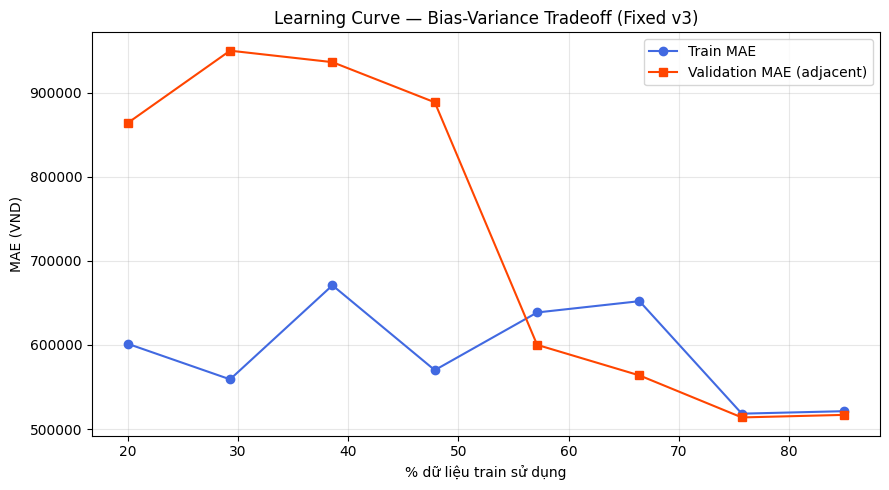

Gap (Val-Train) tại fraction lớn nhất: -4,401 | Gap ratio: -0.8%
 Bias-Variance cân bằng (gap_ratio=-0.8%)


In [11]:

train_sizes_frac = np.linspace(0.2, 0.85, 8)  
train_errs, val_errs = [], []

N = len(X)
VAL_FRAC = 0.10  # mỗi lần dùng 10% tiếp theo làm val

for frac in train_sizes_frac:
    n_train_end = int(N * frac)
    n_val_end   = min(int(N * (frac + VAL_FRAC)), N)

    tr_sub  = np.arange(0, n_train_end)
    val_sub = np.arange(n_train_end, n_val_end)

    if len(tr_sub) < 100 or len(val_sub) < 30:
        continue

    m = lgb.LGBMRegressor(**{**BEST_PARAMS, 'n_estimators': 2000})
    m.fit(
        X[tr_sub], y_log_rev[tr_sub],
        eval_set=[(X[val_sub], y_log_rev[val_sub])],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)]
    )

    train_pred = np.expm1(m.predict(X[tr_sub]))
    val_pred   = np.expm1(m.predict(X[val_sub]))
    train_errs.append(mean_absolute_error(np.expm1(y_log_rev[tr_sub]), train_pred))
    val_errs.append(mean_absolute_error(np.expm1(y_log_rev[val_sub]),   val_pred))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes_frac[:len(train_errs)] * 100, train_errs, 'o-', color='royalblue', label='Train MAE')
ax.plot(train_sizes_frac[:len(val_errs)]   * 100, val_errs,   's-', color='orangered',  label='Validation MAE (adjacent)')
ax.set_xlabel('% dữ liệu train sử dụng')
ax.set_ylabel('MAE (VND)')
ax.set_title('Learning Curve — Bias-Variance Tradeoff (Fixed v3)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curve_v3.png', dpi=150, bbox_inches='tight')
plt.show()

gap       = val_errs[-1] - train_errs[-1]
gap_ratio = gap / train_errs[-1] if train_errs[-1] > 0 else 0
print(f'Gap (Val-Train) tại fraction lớn nhất: {gap:,.0f} | Gap ratio: {gap_ratio:.1%}')

if gap_ratio > 0.25:
    print(f'  High Variance: gap ratio={gap_ratio:.1%} > 25% → tăng reg_lambda')
elif gap_ratio < -0.05:
    print(f'  High Bias: Train MAE > Val MAE → model quá đơn giản, tăng num_leaves')
else:
    print(f' Bias-Variance cân bằng (gap_ratio={gap_ratio:.1%})')


## 8. Final Model Selection & Retrain trên toàn bộ Training Data

In [12]:
params_final_rev  = {**BEST_PARAMS, 'n_estimators': best_n_rev}
params_final_cogs = {**BEST_PARAMS, 'n_estimators': best_n_cogs}

final_model_rev  = lgb.LGBMRegressor(**params_final_rev)
final_model_cogs = lgb.LGBMRegressor(**params_final_cogs)

# Retrain trên toàn bộ train — KHÔNG early stopping (n_estimators đã fixed từ CV)
final_model_rev.fit(X, y_log_rev,   callbacks=[lgb.log_evaluation(-1)])
final_model_cogs.fit(X, y_log_cogs, callbacks=[lgb.log_evaluation(-1)])

if best_n_rev > 500:
    print(f'  best_n_rev={best_n_rev} khá lớn — kiểm tra lại learning curve')
else:
    print(f' best_n_rev={best_n_rev} hợp lý')

print(' Retrain xong trên toàn bộ TRAIN DATA')
print(f'   Train: {df_train["Date"].min().date()} → {df_train["Date"].max().date()}')
print(f'   n_estimators Rev : {final_model_rev.n_estimators}')
print(f'   n_estimators COGS: {final_model_cogs.n_estimators}')


 best_n_rev=275 hợp lý
 Retrain xong trên toàn bộ TRAIN DATA
   Train: 2013-07-04 → 2022-12-31
   n_estimators Rev : 275
   n_estimators COGS: 229


## 9. Recursive Forecast trên Tập Test (01/01/2023 → 01/07/2024)

In [13]:
test_ext = (
    sample_submission[['Date']].copy()
    .merge(web_daily,      on='Date', how='left')
    .merge(stockout_daily, on='Date', how='left')
)
test_ext['daily_sessions'] = test_ext['daily_sessions'].fillna(df_full['daily_sessions'].median())
test_ext['stockout_rate']  = test_ext['stockout_rate'].fillna(0)

print(f'Số ngày cần dự báo: {len(test_ext)}')
print(f'Ngày đầu: {test_ext["Date"].min().date()} | Ngày cuối: {test_ext["Date"].max().date()}')

Số ngày cần dự báo: 548
Ngày đầu: 2023-01-01 | Ngày cuối: 2024-07-01


In [14]:
history = df_full[['Date', 'log_revenue', 'log_cogs']].set_index('Date')

predictions = []

for _, row in test_ext.iterrows():
    date = row['Date']

    row_data = {
        'Date':           date,
        'log_revenue':    np.nan,
        'log_cogs':       np.nan,
        'daily_sessions': row['daily_sessions'],
        'stockout_rate':  row['stockout_rate'],
    }

    tmp_df = pd.concat(
        [history.reset_index(), pd.DataFrame([row_data])],
        ignore_index=True
    ).sort_values('Date').reset_index(drop=True)

    tmp_df = build_features(tmp_df, target_col='log_revenue', cogs_col='log_cogs')

    feat_row = tmp_df.iloc[[-1]][FEATURE_COLS]

    pred_log_rev  = float(final_model_rev.predict(feat_row)[0])
    pred_log_cogs = float(final_model_cogs.predict(feat_row)[0])

    pred_rev  = max(float(np.expm1(pred_log_rev)),  0)
    pred_cogs = max(float(np.expm1(pred_log_cogs)), 0)
    pred_cogs = min(pred_cogs, pred_rev * 0.99)

    predictions.append({'Date': date, 'Revenue': pred_rev, 'COGS': pred_cogs})

    new_row = pd.DataFrame([{
        'Date': date, 'log_revenue': pred_log_rev, 'log_cogs': pred_log_cogs
    }])
    history = pd.concat([history.reset_index(), new_row]).set_index('Date')

pred_df = pd.DataFrame(predictions)
print(f' Dự báo xong: {len(pred_df)} ngày')
print(pred_df.head())
print(f'Revenue range: {pred_df["Revenue"].min():,.0f} → {pred_df["Revenue"].max():,.0f}')

 Dự báo xong: 548 ngày
        Date       Revenue          COGS
0 2023-01-01  1.983366e+06  1.801045e+06
1 2023-01-02  1.604713e+06  1.384640e+06
2 2023-01-03  1.145952e+06  1.045573e+06
3 2023-01-04  1.082268e+06  9.754153e+05
4 2023-01-05  1.093890e+06  9.824044e+05
Revenue range: 866,489 → 8,737,894


## 10. Validation: Thực tế vs Dự báo (Fold cuối)

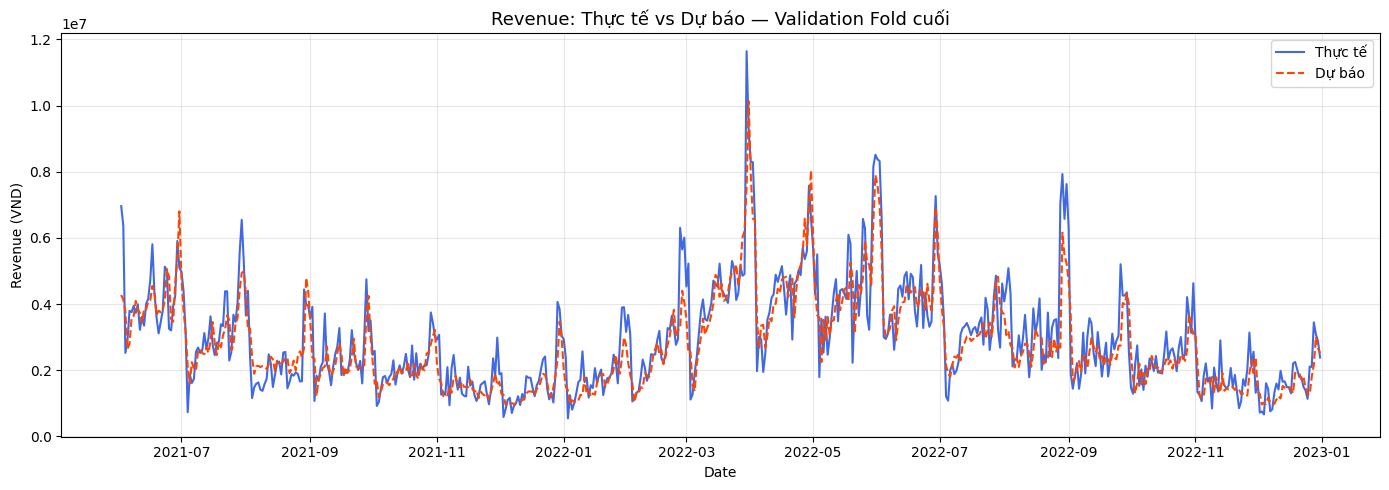

Fold cuối | MAE=   544,973 | RMSE=   768,499 | R²=0.7569
Baseline  | MAE=   617,424 | RMSE=   880,270 | R²=0.7206
Cải thiện | MAE=   +72,451 | R²=+0.0363


In [15]:
splits = list(tscv.split(X))
tr_idx, val_idx = splits[-1]

tmp_model = lgb.LGBMRegressor(**{**BEST_PARAMS, 'n_estimators': best_n_rev})
tmp_model.fit(
    X[tr_idx], y_log_rev[tr_idx],
    eval_set=[(X[val_idx], y_log_rev[val_idx])],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
)

y_pred_plot = np.expm1(tmp_model.predict(X[val_idx]))
y_val_plot  = np.expm1(y_log_rev[val_idx])
val_dates   = df_train.iloc[val_idx]['Date']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(val_dates.values, y_val_plot,  label='Thực tế', color='royalblue', linewidth=1.5)
ax.plot(val_dates.values, y_pred_plot, label='Dự báo',  color='orangered', linewidth=1.5, linestyle='--')
ax.set_title('Revenue: Thực tế vs Dự báo — Validation Fold cuối', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Revenue (VND)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('val_plot_v2.png', dpi=150, bbox_inches='tight')
plt.show()

mae_f  = mean_absolute_error(y_val_plot, y_pred_plot)
rmse_f = np.sqrt(mean_squared_error(y_val_plot, y_pred_plot))
r2_f   = r2_score(y_val_plot, y_pred_plot)
print(f'Fold cuối | MAE={mae_f:>10,.0f} | RMSE={rmse_f:>10,.0f} | R²={r2_f:.4f}')
print(f'Baseline  | MAE={bl_mae:>10,.0f} | RMSE={bl_rmse:>10,.0f} | R²={bl_r2:.4f}')
print(f'Cải thiện | MAE={bl_mae-mae_f:>+10,.0f} | R²={r2_f-bl_r2:>+.4f}')

## 11. SHAP Explainability

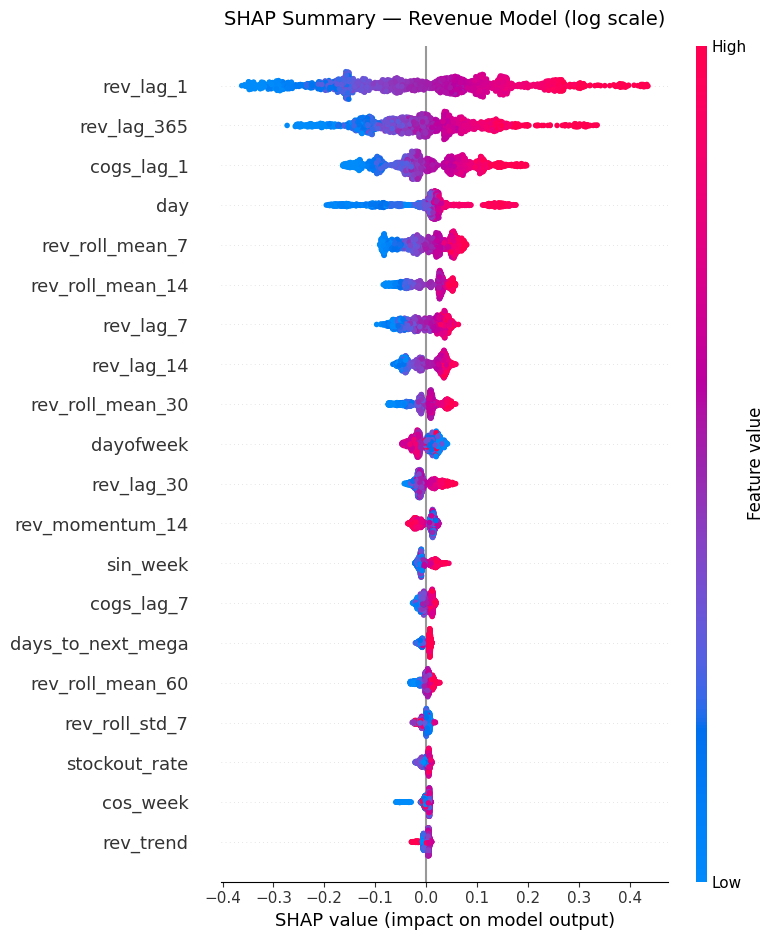

 Lưu shap_summary.png


In [16]:
X_sample = df_train[FEATURE_COLS].sample(min(2000, len(df_train)), random_state=SEED)

explainer   = shap.TreeExplainer(final_model_rev)
shap_values = explainer.shap_values(X_sample)

# ── 11.1 Beeswarm Summary Plot ────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, feature_names=FEATURE_COLS,
                  max_display=20, show=False)
plt.title('SHAP Summary — Revenue Model (log scale)', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Lưu shap_summary.png')

Top 15 features quan trọng nhất:
          Feature  SHAP_mean
        rev_lag_1   0.148663
      rev_lag_365   0.084861
       cogs_lag_1   0.066565
              day   0.054749
  rev_roll_mean_7   0.040616
 rev_roll_mean_14   0.036553
        rev_lag_7   0.031334
       rev_lag_14   0.030402
 rev_roll_mean_30   0.023822
        dayofweek   0.018646
       rev_lag_30   0.018331
  rev_momentum_14   0.015552
         sin_week   0.013367
       cogs_lag_7   0.009399
days_to_next_mega   0.007972


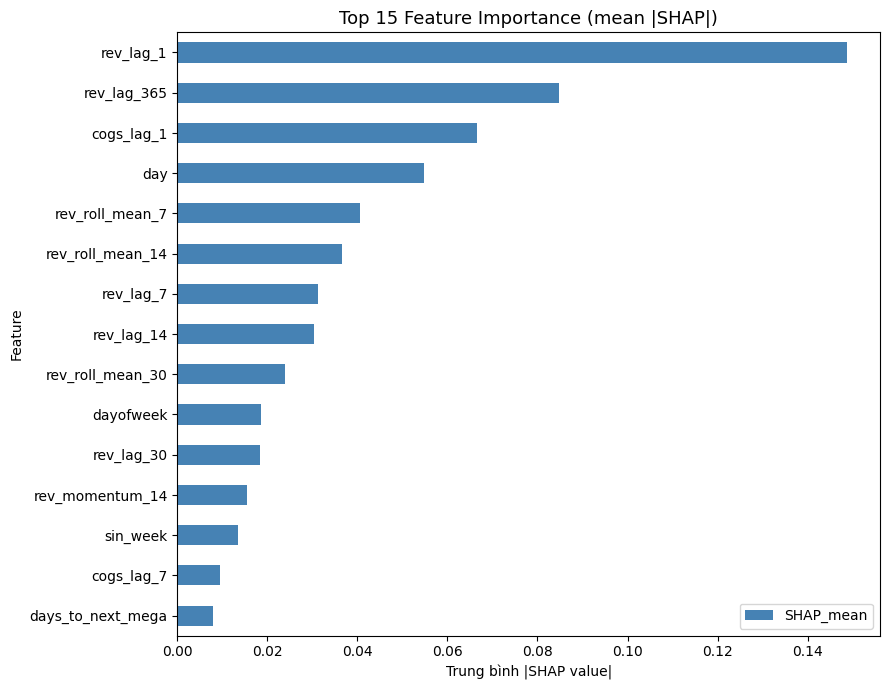

 Lưu shap_bar.png


In [17]:
# ── 11.2 Feature Importance Bar ──────────────────────────────────────
shap_abs_mean = np.abs(shap_values).mean(axis=0)
feat_imp = pd.DataFrame({
    'Feature':   FEATURE_COLS,
    'SHAP_mean': shap_abs_mean,
}).sort_values('SHAP_mean', ascending=False)

print('Top 15 features quan trọng nhất:')
print(feat_imp.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 7))
feat_imp.head(15).plot.barh(x='Feature', y='SHAP_mean', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Top 15 Feature Importance (mean |SHAP|)', fontsize=13)
ax.set_xlabel('Trung bình |SHAP value|')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Lưu shap_bar.png')

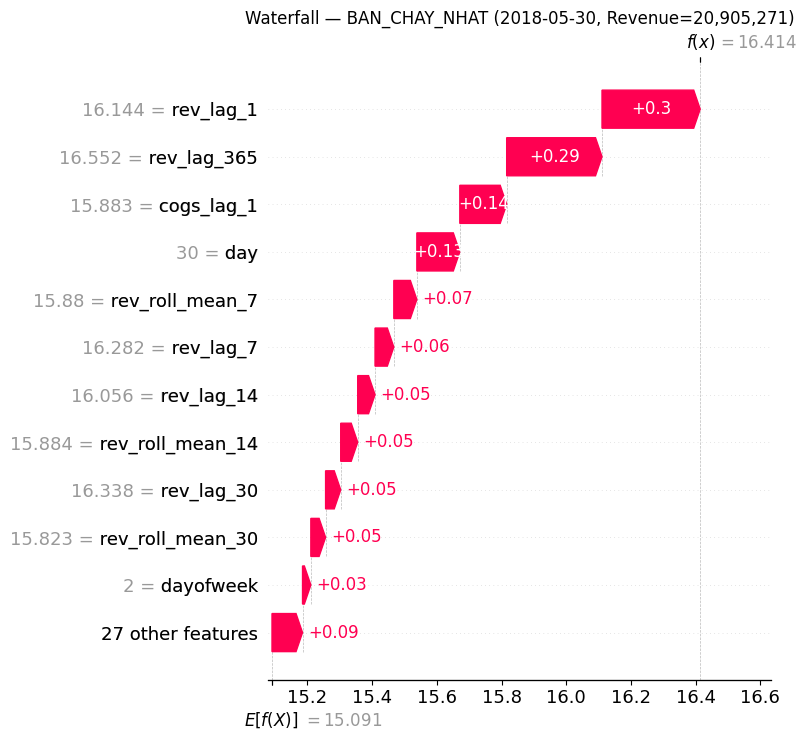

 Lưu shap_waterfall_ban_chay_nhat_v2.png


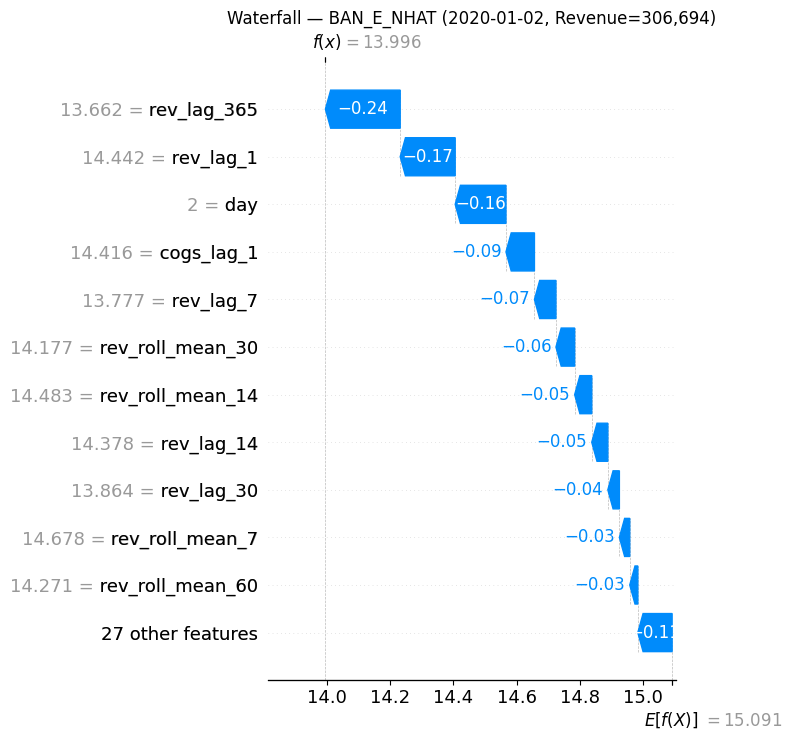

 Lưu shap_waterfall_ban_e_nhat_v2.png


In [18]:
# ── 11.3 Waterfall — ngày bán chạy nhất và ế nhất ───────────────────
best_idx  = df_train['log_revenue'].idxmax()
worst_idx = df_train['log_revenue'].idxmin()

for label, idx in [('BAN_CHAY_NHAT', best_idx), ('BAN_E_NHAT', worst_idx)]:
    row_date = df_train.loc[idx, 'Date']
    row_rev  = np.expm1(df_train.loc[idx, 'log_revenue'])
    feat_row = df_train.loc[[idx], FEATURE_COLS]
    sv = explainer(feat_row)

    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(sv[0], max_display=12, show=False)
    plt.title(f'Waterfall — {label} ({row_date.date()}, Revenue={row_rev:,.0f})', fontsize=12)
    plt.tight_layout()
    fname = f'shap_waterfall_{label.lower()}_v2.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f' Lưu {fname}')

## 12. Tạo submission.csv

In [19]:
submission = sample_submission[['Date']].merge(pred_df, on='Date', how='left')

assert len(submission) == len(sample_submission), '❌ Số dòng không khớp!'
assert submission['Revenue'].isna().sum() == 0,   '❌ Có ngày bị thiếu Revenue!'
assert submission['COGS'].isna().sum() == 0,       '❌ Có ngày bị thiếu COGS!'

submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission = submission[['Date', 'Revenue', 'COGS']]
submission.to_csv('submission.csv', index=False)

print('===  submission.csv đã lưu ===')
print(f'Số dòng  : {len(submission)}')
print(f'Test range: {submission["Date"].min()} → {submission["Date"].max()}')
print(submission.head(5).to_string(index=False))
print('...')
print(submission.tail(3).to_string(index=False))
print(f'\nRevenue min/max: {submission["Revenue"].min():,.0f} / {submission["Revenue"].max():,.0f}')
print(f'COGS    min/max: {submission["COGS"].min():,.0f}   / {submission["COGS"].max():,.0f}')

===  submission.csv đã lưu ===
Số dòng  : 548
Test range: 2023-01-01 → 2024-07-01
      Date      Revenue         COGS
2023-01-01 1.983366e+06 1.801045e+06
2023-01-02 1.604713e+06 1.384640e+06
2023-01-03 1.145952e+06 1.045573e+06
2023-01-04 1.082268e+06 9.754153e+05
2023-01-05 1.093890e+06 9.824044e+05
...
      Date      Revenue         COGS
2024-06-29 5.305667e+06 4.761193e+06
2024-06-30 5.348521e+06 4.845259e+06
2024-07-01 4.195006e+06 3.884470e+06

Revenue min/max: 866,489 / 8,737,894
COGS    min/max: 839,799   / 7,450,444
